# 2、backtrader

In [1]:
open_path = r'C:\Users\蒋大王\Desktop\量化\截面多因子模型\02因子库\processed_data\market_data\open.parquet'
close_path = r'C:\Users\蒋大王\Desktop\量化\截面多因子模型\02因子库\processed_data\market_data\close.parquet'
high_path = r'C:\Users\蒋大王\Desktop\量化\截面多因子模型\02因子库\processed_data\market_data\high.parquet'
low_path = r'C:\Users\蒋大王\Desktop\量化\截面多因子模型\02因子库\processed_data\market_data\low.parquet'
volume_path = r'C:\Users\蒋大王\Desktop\量化\截面多因子模型\02因子库\processed_data\market_data\volume.parquet'
pred_path = r'C:\Users\蒋大王\Desktop\量化\截面多因子模型\03模型训练层\experiments\exp_001\predictions.parquet'
live_pred_path = r'C:\Users\蒋大王\Desktop\量化\截面多因子模型\03模型训练层\experiments\exp_001\live_predictions.parquet'

In [2]:
import pandas as pd
import gc

# ========== 读取数据 ==========
close = pd.read_parquet(close_path)
high = pd.read_parquet(high_path)
low = pd.read_parquet(low_path)
volume = pd.read_parquet(volume_path)
prediction = pd.read_parquet(pred_path)
live_prediction = pd.read_parquet(live_pred_path)

# ========== 转换函数 ==========
def wide_to_long(df_wide, value_name, time_col='time'):
    """宽表转长表，处理完立即释放"""
    df_wide = df_wide.set_index(time_col)
    df_long = df_wide.stack().reset_index()
    df_long.columns = [time_col, 'stock_code', value_name]
    
    # 过滤股票代码：6位数字.SZ/SH/BJ
    df_long = df_long[df_long['stock_code'].str.match(r'^\d{6}\.(SZ|SH|BJ)$', na=False)]
    
    # 转换类型节省内存
    if value_name in ['close', 'high', 'low']:
        df_long[value_name] = df_long[value_name].astype('float32')
    elif value_name == 'volume':
        df_long[value_name] = df_long[value_name].astype('float32')
    
    df_long = df_long.dropna(subset=[value_name])
    return df_long

# ========== 处理 prediction（只读必要列）==========
print("处理 prediction...")
prediction = pd.read_parquet(pred_path, columns=['date', 'stock_code', 'pred_score'])
live_prediction = pd.read_parquet(live_pred_path, columns=['date', 'stock_code', 'pred_score'])

prediction_total = pd.concat([prediction, live_prediction], axis=0)
prediction_total = prediction_total.rename(columns={
    'date': 'time',
    'pred_score': 'prediction'
})
prediction_total['time'] = pd.to_datetime(prediction_total['time'])
prediction_total['prediction'] = prediction_total['prediction'].astype('float32')

del prediction, live_prediction
gc.collect()

print(f"prediction 数据: {len(prediction_total)} 行")

# ========== 逐个处理 price 数据，流式合并 ==========
print("处理 close...")
close_long = wide_to_long(close, 'close')
df = pd.merge(prediction_total, close_long, on=['time', 'stock_code'], how='left')
del close, close_long, prediction_total
gc.collect()

print("处理 high...")
high = pd.read_parquet(high_path)
high_long = wide_to_long(high, 'high')
df = pd.merge(df, high_long, on=['time', 'stock_code'], how='left')
del high, high_long
gc.collect()

print("处理 low...")
low = pd.read_parquet(low_path)
low_long = wide_to_long(low, 'low')
df = pd.merge(df, low_long, on=['time', 'stock_code'], how='left')
del low, low_long
gc.collect()

print("处理 volume...")
volume = pd.read_parquet(volume_path)
volume_long = wide_to_long(volume, 'volume')
df = pd.merge(df, volume_long, on=['time', 'stock_code'], how='left')
del volume, volume_long
gc.collect()

# ========== 最终整理 ==========
df['openinterest'] = 0
df['datetime'] = pd.to_datetime(df['time'])
df = df.set_index('datetime').drop(columns=['time'])

# 股票代码变 category 省内存
df['stock_code'] = df['stock_code'].astype('category')

print(f"\n完成！数据形状: {df.shape}")
print(f"内存占用: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n前5行:\n{df.head()}")

处理 prediction...
prediction 数据: 11349645 行
处理 close...
处理 high...
处理 low...
处理 volume...

完成！数据形状: (11349645, 7)
内存占用: 411.76 MB

前5行:
           stock_code  prediction      close       high       low     volume  \
datetime                                                                       
2013-07-02  000001.SZ   -0.007484   4.163643   4.250385  4.063889   813753.0   
2013-07-02  000002.SZ   -0.004833   6.243195   6.365232  6.037657  1109956.0   
2013-07-02  000004.SZ   -0.011320  10.150000  10.170000  9.900000     8341.0   
2013-07-02  000006.SZ   -0.010588   3.245197   3.260687  3.190982    54040.0   
2013-07-02  000007.SZ   -0.008692   9.418022   9.677968  9.131415    33638.0   

            openinterest  
datetime                  
2013-07-02             0  
2013-07-02             0  
2013-07-02             0  
2013-07-02             0  
2013-07-02             0  


In [7]:
import pandas as pd

# ========== 策略参数 ==========
REBALANCE_PERIOD = 20          # 约月度调仓（20个交易日）
STOCKS_PER_BATCH = 30          # 每次选20只
PREDICTION_COL = 'prediction'  # 预测值列名

# ========== 初始化存储容器 ==========
buy_date = {}
sell_date = {}
position = set()
all_stocks_ever_held = set()

# ========== 选取调仓日期 ==========
# 从 df 的 index 获取所有交易日
trading_days = sorted(df.index.unique())
rebalance_dates = trading_days[::REBALANCE_PERIOD]

print(f"总交易日: {len(trading_days)} | 调仓次数: {len(rebalance_dates)}")

# ========== 主循环：月度调仓 ==========
for date in rebalance_dates:
    trade_date_str = date.strftime('%Y-%m-%d')
    
    # 获取当天的截面数据
    current_slice = df.loc[date]
    
    # 只有一只股票时返回 Series，转成 DataFrame
    if isinstance(current_slice, pd.Series):
        current_slice = current_slice.to_frame().T
    
    if current_slice.empty:
        print(f"警告：{trade_date_str} 无数据，跳过")
        continue
    
    # 按 prediction 排序，选 Top N（prediction 越大越好）
    selected = current_slice.sort_values(
        by=PREDICTION_COL, 
        ascending=False          # False=买大（预测收益高）
    ).head(STOCKS_PER_BATCH)
    
    buy_list = selected['stock_code'].tolist()
    buy_list_set = set(buy_list)
    
    # 生成卖出列表（原持仓中不在新名单里的）
    sell_list = sorted(list(position - buy_list_set))
    
    # 更新记录
    buy_date[trade_date_str] = buy_list
    sell_date[trade_date_str] = sell_list
    position = buy_list_set
    all_stocks_ever_held.update(position)
    
    # 打印日志
    pred_mean = selected[PREDICTION_COL].mean()
    print(f"调仓日: {trade_date_str} | 选中{len(buy_list):3d}只 | "
          f"平均预测值: {pred_mean:+.6f} | 卖出{len(sell_list):3d}只")

# ========== 最终统计 ==========
stock_list = sorted(list(all_stocks_ever_held))
position_sizes = [len(v) for v in buy_date.values()]

print(f"\n{'='*60}")
print(f"策略统计:")
print(f"  总调仓次数: {len(rebalance_dates)}")
print(f"  涉及股票总数: {len(stock_list)} 只（历史累计去重）")
print(f"  平均每次持仓: {sum(position_sizes)/len(position_sizes):.1f} 只")
print(f"  持仓数量范围: {min(position_sizes)} - {max(position_sizes)} 只")

# 换手率分析
sell_sizes = [len(v) for v in sell_date.values()]
avg_sell = sum(sell_sizes) / len(sell_sizes)
avg_pos = sum(position_sizes) / len(position_sizes)
print(f"  平均每次卖出: {avg_sell:.1f} 只")
print(f"  估算换手率: {avg_sell/avg_pos*100:.1f}%")

总交易日: 3077 | 调仓次数: 154
调仓日: 2013-07-02 | 选中 30只 | 平均预测值: +0.003932 | 卖出  0只
调仓日: 2013-07-30 | 选中 30只 | 平均预测值: +0.014427 | 卖出 26只
调仓日: 2013-08-27 | 选中 30只 | 平均预测值: +0.020113 | 卖出 25只
调仓日: 2013-09-26 | 选中 30只 | 平均预测值: +0.012956 | 卖出 25只
调仓日: 2013-10-31 | 选中 30只 | 平均预测值: +0.068344 | 卖出 27只
调仓日: 2013-11-28 | 选中 30只 | 平均预测值: +0.065461 | 卖出 22只
调仓日: 2013-12-26 | 选中 30只 | 平均预测值: +0.067462 | 卖出 17只
调仓日: 2014-01-24 | 选中 30只 | 平均预测值: +0.096268 | 卖出 19只
调仓日: 2014-02-28 | 选中 30只 | 平均预测值: +0.083467 | 卖出 18只
调仓日: 2014-03-28 | 选中 30只 | 平均预测值: +0.080691 | 卖出 15只
调仓日: 2014-04-28 | 选中 30只 | 平均预测值: +0.037578 | 卖出 24只
调仓日: 2014-05-28 | 选中 30只 | 平均预测值: +0.057974 | 卖出 24只
调仓日: 2014-06-26 | 选中 30只 | 平均预测值: +0.073082 | 卖出 17只
调仓日: 2014-07-24 | 选中 30只 | 平均预测值: +0.036264 | 卖出 25只
调仓日: 2014-08-21 | 选中 30只 | 平均预测值: +0.061444 | 卖出 25只
调仓日: 2014-09-19 | 选中 30只 | 平均预测值: +0.091039 | 卖出 21只
调仓日: 2014-10-24 | 选中 30只 | 平均预测值: +0.156268 | 卖出 20只
调仓日: 2014-11-21 | 选中 30只 | 平均预测值: +0.139420 | 卖出 22只
调仓日: 2014-12-19 | 选中 30

In [9]:
# ========== 生成 Backtrader 需要的数据格式 ==========
stock_daily0 = df.reset_index().rename(columns={
    'datetime': 'date',
    'stock_code': '股票代码',
    'close': 'close',
    'high': 'high',
    'low': 'low',
    'openinterest': 'openinterest',
    'volume': 'volume'
})

# 添加 open 列（用 close 代替，或者从数据源读 open）
stock_daily0['open'] = stock_daily0['close']

stock_daily0 = stock_daily0[['股票代码', 'date', 'open', 'high', 'low', 'close', 'volume', 'openinterest']]
stock_daily0["date"] = pd.to_datetime(stock_daily0["date"])
stock_daily0.set_index("date", inplace=True, drop=False)

# 创建日期序列 z1（用于数据对齐）
n1 = len(stock_daily0.date.unique())
z1 = pd.Series(range(0, n1), index=stock_daily0.date.unique()).sort_index()

print(f"stock_daily0 形状: {stock_daily0.shape}")
print(f"日期范围: {stock_daily0.index.min()} ~ {stock_daily0.index.max()}")

stock_daily0 形状: (11349645, 8)
日期范围: 2013-07-02 00:00:00 ~ 2026-02-27 00:00:00


In [12]:
import backtrader as bt
import pandas as pd
from datetime import datetime

# ========== 数据准备（前面生成的）==========
# stock_daily0, z1, buy_date, sell_date, stock_list

def get_data_1(symbol):
    """从长表格取某只股票的数据"""
    stock = stock_daily0[stock_daily0["股票代码"] == symbol][["open", "high", "low", "close", "volume", "openinterest"]]
    stock = pd.concat([stock, z1], axis=1).bfill().ffill()
    return stock[["open", "high", "low", "close", "volume", "openinterest"]]

# ========== 你的原始策略类（完全不变）==========
class my_strategy_date_2(bt.Strategy):
    def __init__(self):
        self.order = None
        self.trade_count = 0  # 统计调仓次数·

    def next(self):
        current_date = str(self.datetime.date(0))
        
        # 记录每日净值
        cash_value.update({current_date: self.broker.getvalue()})
        
        # 检查是否是调仓日
        is_rebalance = (current_date in sell_date.keys()) or (current_date in buy_date.keys())
        
        if is_rebalance:
            self.trade_count += 1
            print(f"\n=== 调仓 #{self.trade_count}: {current_date} ===")
            print(f"当前净值: {self.broker.getvalue():.2f}")
        
        # 卖出
        if current_date in sell_date.keys(): 
            s_list = sell_date[current_date]
            print(f"  卖出 {len(s_list)} 只")
            for i in s_list:
                self.order_target_percent(target=0, data=i)
        
        # 买入
        if current_date in buy_date.keys(): 
            s_list = buy_date[current_date]
            print(f"  买入 {len(s_list)} 只")
            for idx, i in enumerate(s_list, 1):
                if idx % 10 == 0:
                    print(f"    买入进度: {idx}/{len(s_list)}")
                self.order_target_percent(target=0.90/len(s_list), data=i)

    def log(self, txt, dt=None):
        ''' 输出日志'''
        dt = dt or self.datas[0].datetime.date(0) # 拿现在的日期
        print('%s, %s' % (dt.isoformat(), txt))

    def notify_order(self, order):
        if order.status in [order.Submitted, order.Accepted]:
            # Buy/Sell order submitted/accepted to/by broker - Nothing to do
            return

        # Check if an order has been completed
        # Attention: broker could reject order if not enough cash
        if order.status in [order.Completed, order.Canceled, order.Margin]:
            if order.isbuy():
                self.log(f"""买入{order.data._name}, 成交量{order.executed.size}，成交价{order.executed.price:.2f}""")
            elif order.issell():
                self.log(f"""卖出{order.data._name}, 成交量{order.executed.size}，成交价{order.executed.price:.2f}""")
            self.bar_executed = len(self)

        # Write down: no pending order
        self.order = None

# ========== 修改后的回测函数（只加过滤，其他完全不变）==========
def huice_run_num(start, end, stock_list, strategy):
    
    cerebro = bt.Cerebro()
    
    total = len(stock_list)
    for idx, i in enumerate(stock_list, 1):
        stock = get_data_1(i)
        data = bt.feeds.PandasData(dataname=stock, fromdate=start, todate=end)           
        cerebro.adddata(data, name=i)
        
        # 每100只打印进度
        if idx % 100 == 0 or idx == total:
            print(f"加载进度: {idx}/{total} ({idx/total*100:.1f}%)")
        
    cerebro.addstrategy(strategy) 
    cerebro.broker.setcash(100000) 
    cerebro.broker.setcommission(commission=0.002) 

    print(start.date(), end.date())
    print('初始资金: %.2f' % cerebro.broker.getvalue())
    
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='SharpeRatio')
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name='DW')
    cerebro.addanalyzer(bt.analyzers.Returns, _name='Returns', tann=252)
    cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='TradeAnalyzer')

    results = cerebro.run()
    strat = results[0]
    print('最终资金: %.2f' % cerebro.broker.getvalue())
    print('夏普比率:', strat.analyzers.SharpeRatio.get_analysis())
    print('回撤指标:', strat.analyzers.DW.get_analysis())
    
    returns_analysis = strat.analyzers.Returns.get_analysis()
    print('年化收益率: {:.2f}%'.format(returns_analysis['rnorm100']))
    
    trade_analysis = strat.analyzers.TradeAnalyzer.get_analysis()
    if trade_analysis.get('total', {}).get('closed', 0) > 0:
        print('总交易次数:', trade_analysis.total.closed)
        print('盈利交易次数:', trade_analysis.won.total)
        print('亏损交易次数:', trade_analysis.lost.total)
        print('盈利交易占比: {:.2%}'.format(trade_analysis.won.total / trade_analysis.total.closed))
        print('平均每笔盈利: {:.2f}'.format(trade_analysis.won.pnl.average))
        print('平均每笔亏损: {:.2f}'.format(trade_analysis.lost.pnl.average))
    else:
        print('没有交易发生')
    
    return cerebro

# ========== 运行 ==========
from datetime import datetime

start = datetime(2013, 1, 1)
end = datetime(2026, 2, 27)
cash_value = {}

result = huice_run_num(start, end, stock_list, my_strategy_date_2)
cash_plot = pd.Series(cash_value)

加载进度: 100/2039 (4.9%)
加载进度: 200/2039 (9.8%)
加载进度: 300/2039 (14.7%)
加载进度: 400/2039 (19.6%)
加载进度: 500/2039 (24.5%)
加载进度: 600/2039 (29.4%)
加载进度: 700/2039 (34.3%)
加载进度: 800/2039 (39.2%)
加载进度: 900/2039 (44.1%)
加载进度: 1000/2039 (49.0%)
加载进度: 1100/2039 (53.9%)
加载进度: 1200/2039 (58.9%)
加载进度: 1300/2039 (63.8%)
加载进度: 1400/2039 (68.7%)
加载进度: 1500/2039 (73.6%)
加载进度: 1600/2039 (78.5%)
加载进度: 1700/2039 (83.4%)
加载进度: 1800/2039 (88.3%)
加载进度: 1900/2039 (93.2%)
加载进度: 2000/2039 (98.1%)
加载进度: 2039/2039 (100.0%)
2013-01-01 2026-02-27
初始资金: 100000.00

=== 调仓 #1: 2013-07-02 ===
当前净值: 100000.00
  卖出 0 只
  买入 30 只
    买入进度: 10/30
    买入进度: 20/30
    买入进度: 30/30
2013-07-03, 买入600257.SH, 成交量486，成交价6.08
2013-07-03, 买入000665.SZ, 成交量416，成交价7.20
2013-07-03, 买入600455.SH, 成交量247，成交价12.13
2013-07-03, 买入000719.SZ, 成交量580，成交价5.17
2013-07-03, 买入002289.SZ, 成交量235，成交价12.72
2013-07-03, 买入600193.SH, 成交量477，成交价6.18
2013-07-03, 买入000035.SZ, 成交量506，成交价5.93
2013-07-03, 买入600696.SH, 成交量596，成交价4.92
2013-07-03, 买入600084.SH, 成交量722，成交价4

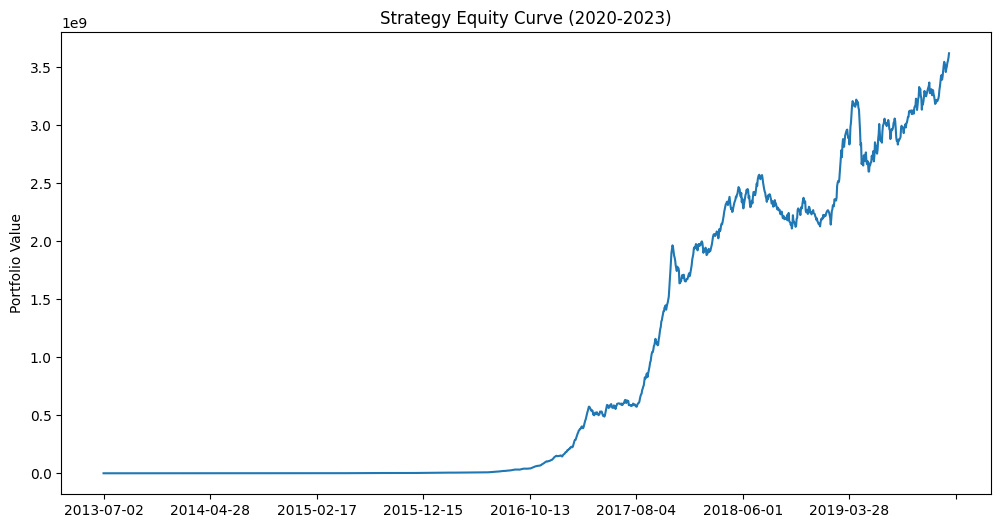

In [ ]:
import matplotlib.pyplot as plt

cash_plot['2013-01-01':'2020-01-01'].plot(figsize=(12, 6), title='Strategy Equity Curve (2020-2023)')
plt.ylabel('Portfolio Value')
plt.show()

## 百分比加固定上限

In [21]:
import backtrader as bt
import pandas as pd
from datetime import datetime

def get_data_1(symbol):
    """从长表格取某只股票的数据"""
    stock = stock_daily0[stock_daily0["股票代码"] == symbol][["open", "high", "low", "close", "volume", "openinterest"]]
    stock = pd.concat([stock, z1], axis=1).bfill().ffill()
    return stock[["open", "high", "low", "close", "volume", "openinterest"]]

class my_strategy_date_2(bt.Strategy):
    params = (
        ('max_cash_per_stock', 50000),  # 单只股票最多5万
        ('total_position_pct', 0.90),   # 总仓位90%
    )
    
    def __init__(self):
        self.order = None
        self.trade_count = 0
        self.datadict = {d._name: d for d in self.datas}

    def next(self):
        current_date = str(self.datetime.date(0))
        cash_value.update({current_date: self.broker.getvalue()})
        
        is_rebalance = (current_date in sell_date.keys()) or (current_date in buy_date.keys())
        
        if is_rebalance:
            self.trade_count += 1
            print(f"\n=== 调仓 #{self.trade_count}: {current_date} ===")
            print(f"当前净值: {self.broker.getvalue():.2f}")
        
        # 卖出
        if current_date in sell_date.keys(): 
            s_list = sell_date[current_date]
            print(f"  卖出 {len(s_list)} 只")
            for i in s_list:
                if i in self.datadict:
                    self.order_target_percent(target=0, data=i)
        
        # 买入：等权，但有上限
        if current_date in buy_date.keys(): 
            s_list = buy_date[current_date]
            print(f"  买入 {len(s_list)} 只")
            
            # 计算每只的目标金额（等权）
            total_cash = self.broker.getvalue() * self.params.total_position_pct
            cash_per_stock = total_cash / len(s_list)
            
            # 限制单只上限
            cash_per_stock = min(cash_per_stock, self.params.max_cash_per_stock)
            
            for idx, i in enumerate(s_list, 1):
                if idx % 10 == 0:
                    print(f"    买入进度: {idx}/{len(s_list)}")
                
                if i in self.datadict:
                    data = self.datadict[i]
                    close_price = data.close[0]
                    
                    if close_price > 0:
                        # 计算股数（100的整数倍）
                        size = int(cash_per_stock / close_price / 100) * 100
                        
                        if size > 0:
                            self.buy(data=data, size=size)

    def log(self, txt, dt=None):
        dt = dt or self.datas[0].datetime.date(0)
        print('%s, %s' % (dt.isoformat(), txt))

    def notify_order(self, order):
        if order.status in [order.Submitted, order.Accepted]:
            return
        if order.status in [order.Completed, order.Canceled, order.Margin]:
            if order.isbuy():
                self.log(f"""买入{order.data._name}, 成交量{order.executed.size}，成交价{order.executed.price:.2f}""")
            elif order.issell():
                self.log(f"""卖出{order.data._name}, 成交量{order.executed.size}，成交价{order.executed.price:.2f}""")
            self.bar_executed = len(self)
        self.order = None

# ========== 回测函数（不变）==========
def huice_run_num(start, end, stock_list, strategy):
    cerebro = bt.Cerebro()
    
    total = len(stock_list)
    for idx, i in enumerate(stock_list, 1):
        stock = get_data_1(i)
        data = bt.feeds.PandasData(dataname=stock, fromdate=start, todate=end)           
        cerebro.adddata(data, name=i)
        
        if idx % 100 == 0 or idx == total:
            print(f"加载进度: {idx}/{total} ({idx/total*100:.1f}%)")
        
    cerebro.addstrategy(strategy) 
    cerebro.broker.setcash(100000) 
    cerebro.broker.setcommission(commission=0.002) 

    print(start.date(), end.date())
    print('初始资金: %.2f' % cerebro.broker.getvalue())
    
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='SharpeRatio')
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name='DW')
    cerebro.addanalyzer(bt.analyzers.Returns, _name='Returns', tann=252)
    cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='TradeAnalyzer')

    results = cerebro.run()
    strat = results[0]
    print('最终资金: %.2f' % cerebro.broker.getvalue())
    print('夏普比率:', strat.analyzers.SharpeRatio.get_analysis())
    print('回撤指标:', strat.analyzers.DW.get_analysis())
    
    returns_analysis = strat.analyzers.Returns.get_analysis()
    print('年化收益率: {:.2f}%'.format(returns_analysis['rnorm100']))
    
    trade_analysis = strat.analyzers.TradeAnalyzer.get_analysis()
    if trade_analysis.get('total', {}).get('closed', 0) > 0:
        print('总交易次数:', trade_analysis.total.closed)
        print('盈利交易次数:', trade_analysis.won.total)
        print('亏损交易次数:', trade_analysis.lost.total)
        print('盈利交易占比: {:.2%}'.format(trade_analysis.won.total / trade_analysis.total.closed))
        print('平均每笔盈利: {:.2f}'.format(trade_analysis.won.pnl.average))
        print('平均每笔亏损: {:.2f}'.format(trade_analysis.lost.pnl.average))
    else:
        print('没有交易发生')
    
    return cerebro

# ========== 运行 ==========
from datetime import datetime

start = datetime(2013, 1, 1)
end = datetime(2026, 2, 27)
cash_value = {}

result = huice_run_num(start, end, stock_list, my_strategy_date_2)
cash_plot = pd.Series(cash_value)

加载进度: 100/2039 (4.9%)
加载进度: 200/2039 (9.8%)
加载进度: 300/2039 (14.7%)
加载进度: 400/2039 (19.6%)
加载进度: 500/2039 (24.5%)
加载进度: 600/2039 (29.4%)
加载进度: 700/2039 (34.3%)
加载进度: 800/2039 (39.2%)
加载进度: 900/2039 (44.1%)
加载进度: 1000/2039 (49.0%)
加载进度: 1100/2039 (53.9%)
加载进度: 1200/2039 (58.9%)
加载进度: 1300/2039 (63.8%)
加载进度: 1400/2039 (68.7%)
加载进度: 1500/2039 (73.6%)
加载进度: 1600/2039 (78.5%)
加载进度: 1700/2039 (83.4%)
加载进度: 1800/2039 (88.3%)
加载进度: 1900/2039 (93.2%)
加载进度: 2000/2039 (98.1%)
加载进度: 2039/2039 (100.0%)
2013-01-01 2026-02-27
初始资金: 100000.00

=== 调仓 #1: 2013-07-02 ===
当前净值: 100000.00
  卖出 0 只
  买入 30 只
    买入进度: 10/30
    买入进度: 20/30
    买入进度: 30/30
2013-07-03, 买入600257.SH, 成交量400，成交价6.08
2013-07-03, 买入000665.SZ, 成交量400，成交价7.20
2013-07-03, 买入600455.SH, 成交量200，成交价12.13
2013-07-03, 买入000719.SZ, 成交量500，成交价5.17
2013-07-03, 买入002289.SZ, 成交量200，成交价12.72
2013-07-03, 买入600193.SH, 成交量400，成交价6.18
2013-07-03, 买入000035.SZ, 成交量500，成交价5.93
2013-07-03, 买入600696.SH, 成交量500，成交价4.92
2013-07-03, 买入600084.SH, 成交量700，成交价4

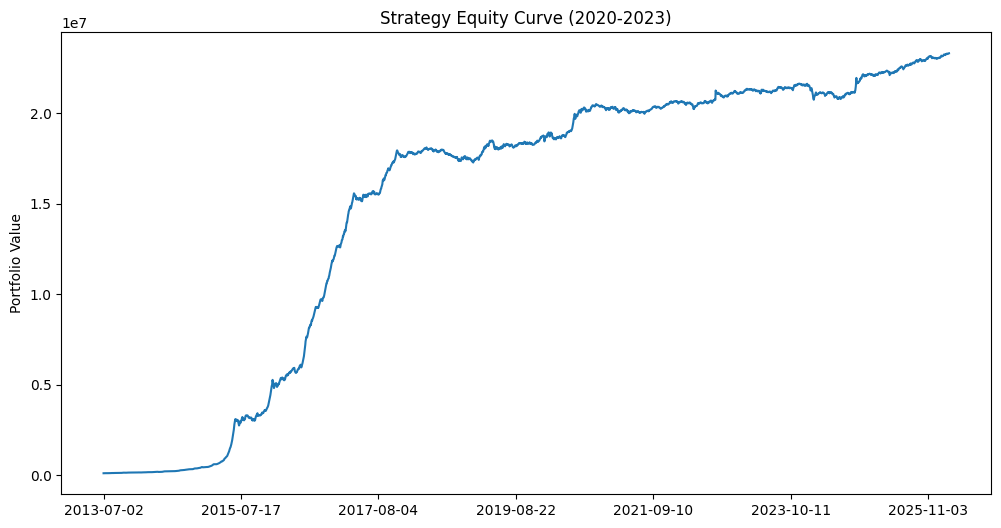

In [23]:
import matplotlib.pyplot as plt

cash_plot.plot(figsize=(12, 6), title='Strategy Equity Curve (2020-2023)')
plt.ylabel('Portfolio Value')
plt.show()

In [41]:
# 只保留 2020-2023 年会交易的股票
relevant = set()

# 买
for d, stocks in buy_date.items():
    date = datetime.strptime(d, '%Y-%m-%d')
    if datetime(2020, 1, 1) <= date < datetime(2023, 1, 1):
        relevant.update(stocks)

# 卖（关键：也要加进来！）
for d, stocks in sell_date.items():
    date = datetime.strptime(d, '%Y-%m-%d')
    if datetime(2020, 1, 1) <= date < datetime(2023, 1, 1):
        relevant.update(stocks)

filtered_list = [s for s in stock_list if s in relevant]
print(f"3年回测涉及股票: {len(filtered_list)} 只")

start = datetime(2020, 1, 1)
end = datetime(2023, 1, 1)
cash_value = {}

result = huice_run_num(start, end, filtered_list, my_strategy_date_2)
cash_plot = pd.Series(cash_value)

3年回测涉及股票: 498 只
加载进度: 100/498 (20.1%)
加载进度: 200/498 (40.2%)
加载进度: 300/498 (60.2%)
加载进度: 400/498 (80.3%)
加载进度: 498/498 (100.0%)
2020-01-01 2023-01-01
初始资金: 100000.00

=== 调仓 #1: 2020-01-20 ===
当前净值: 100000.00
  卖出 10 只
  买入 20 只
    买入进度: 10/20
    买入进度: 20/20
2020-01-21, 买入300812.SZ, 成交量137，成交价36.02
2020-01-21, 买入300638.SZ, 成交量368，成交价12.20
2020-01-21, 买入300813.SZ, 成交量251，成交价19.68
2020-01-21, 买入002971.SZ, 成交量240，成交价20.62
2020-01-21, 买入000719.SZ, 成交量784，成交价5.77
2020-01-21, 买入600566.SH, 成交量232，成交价20.78
2020-01-21, 买入601336.SH, 成交量109，成交价39.91
2020-01-21, 买入603610.SH, 成交量255，成交价17.10
2020-01-21, 买入300771.SZ, 成交量190，成交价23.40
2020-01-21, 买入300761.SZ, 成交量156，成交价26.91
2020-01-21, 买入603466.SH, 成交量641，成交价6.81
2020-01-21, 买入002102.SZ, 成交量2054，成交价2.26
2020-01-21, 买入000681.SZ, 成交量247，成交价17.90
2020-01-21, 买入002607.SZ, 成交量245，成交价17.71
2020-01-21, 买入603187.SH, 成交量435，成交价10.01
2020-01-21, 买入300776.SZ, 成交量114，成交价38.43
2020-01-21, 买入600587.SH, 成交量419，成交价11.39
2020-01-21, 买入300697.SZ, 成交量681，成交价6.54
2020-

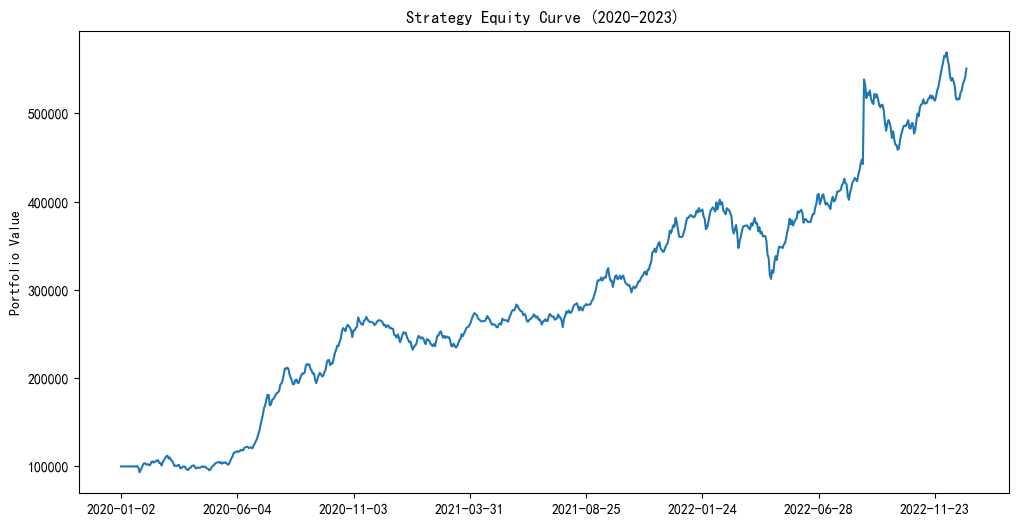

In [43]:
import matplotlib.pyplot as plt

cash_plot.plot(figsize=(12, 6), title='Strategy Equity Curve (2020-2023)')
plt.ylabel('Portfolio Value')
plt.show()

In [146]:
# 策略参数定义 、初始化存储容器
REBALANCE_PERIOD = 20
STOCKS_PER_FACTOR = 50

buy_date = {}
sell_date = {}
position = set()
stock_list = set()
#all_stocks_ever_held = set()

# 选取调仓日期
potential_rebalance_dates = sorted(top_factors_by_day['日期'].unique())
rebalance_dates = potential_rebalance_dates[::REBALANCE_PERIOD]

for date in rebalance_dates:
    trade_date_str = date.strftime('%Y-%m-%d')
    
    # 1. 直接从 top_factors_by_day 获取当天的顶级因子信息
    valid_top_factors = top_factors_by_day[top_factors_by_day['日期'] == date]
    
    # 2. 提取当天的所有股票因子数据 (请确保列名是 "date" 还是 "时间")
    current_stock = stock_daily0[stock_daily0["时间"] == date] 
    if current_stock.empty:
        print(f"警告：交易日 {trade_date_str} 在原始数据中无股票数据，跳过调仓")
        continue

    # 3. 因子筛选与选股逻辑
    buy_list_set = set()
    print(f"调仓日: {trade_date_str}")

    # 遍历当天选出的 N 个因子槽位
    for _, row in valid_top_factors.iterrows():
        factor_name = row['因子名称']
        
        # 【核心修改点 1】：判断因子名是否为 NaN（对应你之前要求的保留行逻辑）
        if pd.isna(factor_name):
            print(f"  排名第 {row['排名']} 的因子未达 IC 阈值，跳过选股")
            continue
            
        # 【核心修改点 2】：将 factor_icir 改为 factor_ic，对应新的选取基准
        factor_ic = row['滚动IC均值']
        
        # 方向判断：IC < 0 则升序（买因子值小的），IC > 0 则降序（买因子值大的）
        asc = (factor_ic < 0)

        # 使用当前的因子名进行排序选股
        selected_stocks = current_stock.sort_values(
            by=factor_name, 
            ascending=asc
        )["股票代码"].head(STOCKS_PER_FACTOR).tolist()
        
        buy_list_set.update(selected_stocks)
        # 【核心修改点 3】：日志信息同步更新为 IC
        print(f"  使用因子: {factor_name} | 滚动IC均值: {factor_ic:.4f} | 方向: {'买小(升序)' if asc else '买大(降序)'} (选出 {len(selected_stocks)} 只)")

    # 如果当天所有因子槽位都是 NaN，说明市场信号极弱，buy_list_set 会是空的
    if not buy_list_set:
        print(f"  结果：当天无任何有效因子满足 IC 阈值，执行清仓/空仓操作。")
        buy_list = []
    else:
        buy_list = sorted(list(buy_list_set))

    # 4. 生成卖出列表
    sell_list = sorted(list(position - set(buy_list)))
    
    # 5. 更新持仓和记录
    buy_date[trade_date_str] = buy_list
    sell_date[trade_date_str] = sell_list
    position = set(buy_list)
    all_stocks_ever_held.update(position)
    
    # 6. 打印调仓详情
    print(f"  计划买入 {len(buy_list)} 只股票 | 计划卖出 {len(sell_list)} 只股票")
    print("-" * 80)

# 更新回测用的股票列表
stock_list = sorted(list(all_stocks_ever_held))
print(f"\n策略回测将涉及 {len(stock_list)} 只股票。")

NameError: name 'top_factors_by_day' is not defined

## 2VectorBT

In [9]:
# ========== 3. 转成矩阵 ==========

pred_matrix = predictions.pivot(
    index='date',
    columns='stock_code',
    values='pred_score'
)
pred_matrix = pred_matrix[common_stocks]
price_matrix = prices.loc[common_dates, common_stocks]
price_matrix.index = pred_matrix.index

print(f"\n预测矩阵: {pred_matrix.shape}")
print(f"价格矩阵: {price_matrix.shape}")

# ========== 新增：数据清洗 ==========

# 1. 检查并报告原始数据问题
print(f"\n价格矩阵NaN数量: {price_matrix.isna().sum().sum()}")
print(f"价格矩阵Inf数量: {np.isinf(price_matrix.values).sum()}")
print(f"价格矩阵0值数量: {(price_matrix == 0).sum().sum()}")
print(f"价格矩阵负数数量: {(price_matrix < 0).sum().sum()}")

# 2. 前向填充价格（处理停牌导致的NaN）
price_matrix = price_matrix.ffill()

# 3. 删除全为NaN的列（退市股票）
all_nan_cols = price_matrix.columns[price_matrix.isna().all()]
if len(all_nan_cols) > 0:
    print(f"删除全NaN股票: {len(all_nan_cols)} 只")
    price_matrix = price_matrix.drop(columns=all_nan_cols)
    pred_matrix = pred_matrix.drop(columns=all_nan_cols, errors='ignore')

# 4. 删除任何包含NaN的行（避免未来函数争议，或填充）
# 方案A：删除该日期所有股票（严格）
# price_matrix = price_matrix.dropna()
# pred_matrix = pred_matrix.loc[price_matrix.index]

# 方案B：用列均值填充（推荐）
price_matrix = price_matrix.fillna(price_matrix.mean(axis=1), axis=0)

# 5. 确保价格 > 0
price_matrix = price_matrix.replace(0, np.nan)  # 0值转为NaN
price_matrix = price_matrix.ffill().bfill()      # 前后填充
price_matrix = price_matrix.clip(lower=0.01)     # 最小价格0.01

# 6. 再次检查
assert price_matrix.isna().sum().sum() == 0, "仍有NaN存在"
assert (price_matrix <= 0).sum().sum() == 0, "仍有非正价格"
assert np.isinf(price_matrix.values).sum() == 0, "仍有Inf存在"

print(f"\n清洗后价格矩阵: {price_matrix.shape}")
print(f"价格范围: {price_matrix.min().min():.2f} ~ {price_matrix.max().max():.2f}")

# ========== 4. 生成信号 ==========

# 确保信号矩阵与价格矩阵对齐
common_cols = price_matrix.columns.intersection(pred_matrix.columns)
price_matrix = price_matrix[common_cols]
pred_matrix = pred_matrix[common_cols]

def get_top_n_signals(pred_df, n=50):
    # 将NaN预测值设为负无穷，避免选入
    pred_df = pred_df.fillna(-np.inf)
    ranks = pred_df.rank(axis=1, ascending=False, method='first')
    signals = ranks <= n
    return signals

entry_signals = get_top_n_signals(pred_matrix, n=50)
exit_signals = entry_signals.shift(20).fillna(False).astype(bool)

# 确保信号矩阵与价格矩阵行列完全一致
entry_signals = entry_signals.reindex(index=price_matrix.index, columns=price_matrix.columns, fill_value=False)
exit_signals = exit_signals.reindex(index=price_matrix.index, columns=price_matrix.columns, fill_value=False)

print(f"\n买入信号: {entry_signals.sum().sum()} 次")
print(f"每天平均买入: {entry_signals.sum(axis=1).mean():.1f} 只")


预测矩阵: (3057, 5183)
价格矩阵: (3057, 5183)

价格矩阵NaN数量: 4576314
价格矩阵Inf数量: 0
价格矩阵0值数量: 0
价格矩阵负数数量: 0

清洗后价格矩阵: (3057, 5183)
价格范围: 0.27 ~ 2279.80


C:\Users\蒋大王\AppData\Local\Temp\ipykernel_15708\1885039197.py:69: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  exit_signals = entry_signals.shift(20).fillna(False).astype(bool)



买入信号: 152850 次
每天平均买入: 50.0 只


预测数据: 11246047 条
价格数据: (3920, 5190)
共同日期: 3057 天
共同股票: 5183 只

预测矩阵: (3057, 5183)
价格矩阵: (3057, 5183)

价格矩阵NaN数量: 4576314
清洗后价格矩阵: (3057, 5183)
价格范围: 0.27 ~ 2279.80

对齐后矩阵: (3057, 5183)
买入信号: 152850 次
每天平均买入: 50.0 只

总收益率: 11979.28%
年化收益率: 77.25%
夏普比率: 1.11
最大回撤: -85.20%
总交易次数: 186


c:\Python\envs\AKTool\Lib\site-packages\vectorbt\generic\plots_builder.py:339: UserWarning: Subplot 'orders' does not support grouped data
  warnings.warn(warning_message)
c:\Python\envs\AKTool\Lib\site-packages\vectorbt\generic\plots_builder.py:339: UserWarning: Subplot 'trade_pnl' does not support grouped data
  warnings.warn(warning_message)



图表已保存到: 回测结果.html


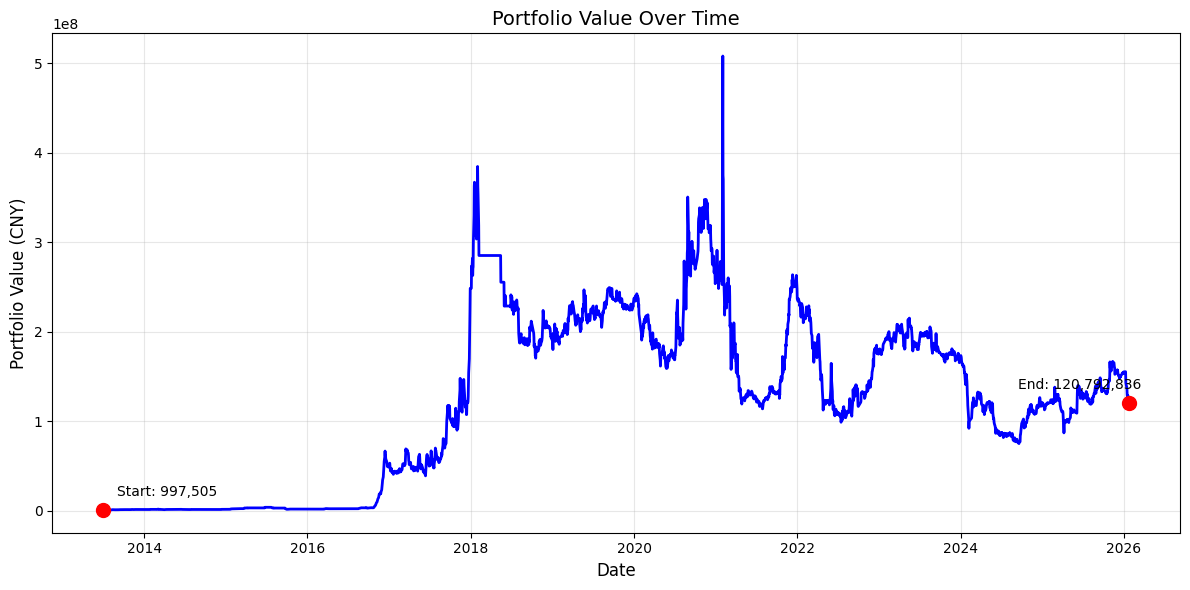

净值曲线已保存到: 净值曲线.png


In [10]:
import pandas as pd
import vectorbt as vbt
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 消除警告
pd.set_option('future.no_silent_downcasting', True)

# ========== 1. 加载数据 ==========

ROOT_DIR = Path(r"C:\Users\蒋大王\Desktop\量化\截面多因子模型")
exp_id = "exp_001"

pred_path = ROOT_DIR / "03模型训练层" / "experiments" / exp_id / "predictions.parquet"
price_path = ROOT_DIR / "02因子库" / "processed_data" / "market_data" / "close.parquet"

# 加载预测数据
predictions = pd.read_parquet(pred_path)
if isinstance(predictions.index, pd.MultiIndex):
    predictions = predictions.reset_index()
predictions['date'] = pd.to_datetime(predictions['date'])

# 加载价格数据
prices = pd.read_parquet(price_path)
if 'time' in prices.columns:
    prices = prices.set_index('time')
prices.index = pd.to_datetime(prices.index)

print(f"预测数据: {len(predictions)} 条")
print(f"价格数据: {prices.shape}")

# ========== 2. 数据对齐 ==========

common_dates = sorted(set(predictions['date']).intersection(prices.index))
print(f"共同日期: {len(common_dates)} 天")

predictions = predictions[predictions['date'].isin(common_dates)]
prices = prices.loc[common_dates]

pred_stocks = set(predictions['stock_code'].unique())
price_stocks = set(prices.columns)
common_stocks = sorted(pred_stocks.intersection(price_stocks))
print(f"共同股票: {len(common_stocks)} 只")

# ========== 3. 转成矩阵 ==========

pred_matrix = predictions.pivot(
    index='date',
    columns='stock_code',
    values='pred_score'
)
pred_matrix = pred_matrix[common_stocks]
price_matrix = prices.loc[common_dates, common_stocks]
price_matrix.index = pred_matrix.index

print(f"\n预测矩阵: {pred_matrix.shape}")
print(f"价格矩阵: {price_matrix.shape}")

# ========== 数据清洗 ==========

print(f"\n价格矩阵NaN数量: {price_matrix.isna().sum().sum()}")

# 1. 前向填充价格（处理停牌）
price_matrix = price_matrix.ffill()

# 2. 删除全为NaN的列（退市股票）
all_nan_cols = price_matrix.columns[price_matrix.isna().all()]
if len(all_nan_cols) > 0:
    print(f"删除全NaN股票: {len(all_nan_cols)} 只")
    price_matrix = price_matrix.drop(columns=all_nan_cols)
    pred_matrix = pred_matrix.drop(columns=all_nan_cols, errors='ignore')

# 3. 用列均值填充剩余NaN
price_matrix = price_matrix.fillna(price_matrix.mean(axis=0))

# 4. 确保价格 > 0
price_matrix = price_matrix.replace(0, np.nan)
price_matrix = price_matrix.ffill().bfill()
price_matrix = price_matrix.clip(lower=0.01)

# 验证
assert price_matrix.isna().sum().sum() == 0, "仍有NaN"
assert (price_matrix <= 0).sum().sum() == 0, "仍有非正价格"

print(f"清洗后价格矩阵: {price_matrix.shape}")
print(f"价格范围: {price_matrix.min().min():.2f} ~ {price_matrix.max().max():.2f}")

# ========== 4. 生成信号 ==========

# 确保两个矩阵行列完全一致
common_idx = price_matrix.index.intersection(pred_matrix.index)
common_cols = price_matrix.columns.intersection(pred_matrix.columns)

price_matrix = price_matrix.loc[common_idx, common_cols]
pred_matrix = pred_matrix.loc[common_idx, common_cols]

print(f"\n对齐后矩阵: {price_matrix.shape}")

def get_top_n_signals(pred_df, n=50):
    # NaN预测值设为负无穷，避免选入
    pred_clean = pred_df.fillna(-np.inf)
    ranks = pred_clean.rank(axis=1, ascending=False, method='first')
    signals = ranks <= n
    return signals

entry_signals = get_top_n_signals(pred_matrix, n=50)

# 修复FutureWarning：先infer_objects再astype
exit_signals = entry_signals.shift(20).infer_objects(copy=False).fillna(False).astype(bool)

# 确保信号与价格完全对齐（重要！）
entry_signals = entry_signals.reindex(
    index=price_matrix.index, 
    columns=price_matrix.columns, 
    fill_value=False
)
exit_signals = exit_signals.reindex(
    index=price_matrix.index, 
    columns=price_matrix.columns, 
    fill_value=False
)

print(f"买入信号: {entry_signals.sum().sum()} 次")
print(f"每天平均买入: {entry_signals.sum(axis=1).mean():.1f} 只")

# ========== 5. 运行回测 ==========

portfolio = vbt.Portfolio.from_signals(
    close=price_matrix,
    entries=entry_signals,
    exits=exit_signals,
    freq='1d',
    init_cash=1000000,
    fees=0.0015,
    slippage=0.001,
    direction='longonly',
    group_by=True,
    cash_sharing=True,
)

# ========== 6. 看结果 ==========

print(f"\n{'='*50}")
print(f"总收益率: {portfolio.total_return():.2%}")
print(f"年化收益率: {portfolio.annualized_return():.2%}")
print(f"夏普比率: {portfolio.sharpe_ratio():.2f}")
print(f"最大回撤: {portfolio.max_drawdown():.2%}")
print(f"总交易次数: {portfolio.trades.count()}")

# ========== 7. 保存图表 ==========

# 保存为HTML（交互式）
fig = portfolio.plot()
fig.write_html("回测结果.html")
print("\n图表已保存到: 回测结果.html")

# 用matplotlib画净值曲线
value = portfolio.value()

plt.figure(figsize=(12, 6))
plt.plot(value.index, value.values, linewidth=2, color='blue')
plt.title('Portfolio Value Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (CNY)', fontsize=12)
plt.grid(True, alpha=0.3)

# 添加起始和结束标注
plt.scatter([value.index[0], value.index[-1]], 
            [value.values[0], value.values[-1]], 
            color='red', s=100, zorder=5)
plt.annotate(f'Start: {value.values[0]:,.0f}', 
             xy=(value.index[0], value.values[0]),
             xytext=(10, 10), textcoords='offset points')
plt.annotate(f'End: {value.values[-1]:,.0f}', 
             xy=(value.index[-1], value.values[-1]),
             xytext=(-80, 10), textcoords='offset points')

plt.tight_layout()
plt.savefig('净值曲线.png', dpi=300, bbox_inches='tight')
plt.show()

print("净值曲线已保存到: 净值曲线.png")

In [52]:
a = pd.read_csv(r'C:\Users\蒋大王\Desktop\量化\截面多因子模型\04回测层\reports\exp_001\trade_records.csv')
a

,调仓序号,日期,净值,买入数量,卖出数量,买入股票列表,卖出股票列表,换手率(%)
0,1,2020-12-17,100000.0,30,25,003020.SZ;605151.SH;605376.SH;003025.SZ;605058...,000615.SZ;000679.SZ;000727.SZ;000977.SZ;000987...,0


In [3]:
import pandas as pd
df = pd.read_parquet(r'C:\Users\蒋大王\Desktop\量化\截面多因子模型\03模型训练层\experiments\test_2020_2026_v1\predictions.parquet')
df


,date,stock_code,pred_score,actual_return,fold_id
0,2023-10-20,000001.SZ,0.017819,-0.041549,0
1,2023-10-20,000002.SZ,0.019591,0.011226,0
2,2023-10-20,000004.SZ,-0.005348,0.178681,0
3,2023-10-20,000006.SZ,0.013395,0.071090,0
4,2023-10-20,000007.SZ,0.006673,0.105495,0
...,...,...,...,...,...
2826749,2026-01-21,688807.SH,-0.003808,0.081340,8
2826750,2026-01-21,688809.SH,-0.018269,-0.010384,8
2826751,2026-01-21,688819.SH,0.016665,-0.030174,8
2826752,2026-01-21,688981.SH,0.043022,-0.108156,8
